In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

PROJECT_ROOT = Path("..").resolve()

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
FIGURES_DIR = PROJECT_ROOT / "figures"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

candidates_path = PROCESSED_DIR / "gaia_lamost_larger_chemo_kinematic_candidates.csv"
features_path = PROCESSED_DIR / "gaia_lamost_larger_velocity_features.csv"

print("Project root:", PROJECT_ROOT)
print("Candidates exists:", candidates_path.exists(), candidates_path)
print("Features exists:", features_path.exists(), features_path)

Project root: /Users/liors/Documents/gaia-lamost-galactic-archaeology
Candidates exists: True /Users/liors/Documents/gaia-lamost-galactic-archaeology/data/processed/gaia_lamost_larger_chemo_kinematic_candidates.csv
Features exists: True /Users/liors/Documents/gaia-lamost-galactic-archaeology/data/processed/gaia_lamost_larger_velocity_features.csv


In [2]:
candidates = pd.read_csv(candidates_path)
features = pd.read_csv(features_path)

print("Candidates shape:", candidates.shape)
print("Features shape:", features.shape)

display(candidates.head())
display(features.head())

Candidates shape: (27, 31)
Features shape: (1838, 47)


,source_id,ra_gaia,dec_gaia,gal_l,gal_b,gal_l_astropy,gal_b_astropy,parallax,distance_pc,bp_rp,phot_g_mean_mag,absolute_g_mag,teff,logg,feh,rv,pm_total,tangential_velocity_kms,reduced_pm_g,galcen_x_kpc,galcen_y_kpc,galcen_z_kpc,galcen_vx_kms,galcen_vy_kms,galcen_vz_kms,galcen_vtot_kms,metallicity_group,high_vtan_candidate,metal_poor_candidate,chemo_kinematic_candidate,coord_match_sep_arcsec
0,3084618814470882048,121.206776,1.036917,220.578098,16.759371,220.578098,16.759371,0.239175,4181.041412,1.171156,15.836410,2.729987,4737.68,3.709,-0.951,127.33,8.330490,165.111147,10.439762,-11.159579,-2.604178,1.234190,-52.362524,72.487760,-88.384340,125.730270,metal_poor,True,True,True,0.028884
1,3077610566011025408,124.849144,0.784451,222.635197,19.843864,222.635197,19.843864,0.160951,6213.063298,1.175033,13.772771,-0.193758,4813.31,2.214,-0.543,93.57,3.406003,100.316453,6.433996,-12.415988,-3.958398,2.140867,-123.879403,251.688003,16.328023,280.997440,metal_poor,True,True,True,0.056867
2,3083553117121981312,123.113104,0.459705,222.058099,18.164211,222.058099,18.164211,0.075795,13193.564091,1.549932,13.163137,-2.438673,4252.85,0.992,-1.116,91.38,3.797959,237.538396,6.060889,-17.419042,-8.397720,4.157578,76.094271,5.180934,-46.809029,89.488912,metal_poor,True,True,True,0.058795
3,3083753361380495744,122.455722,0.527457,221.666424,17.618518,221.666424,17.618518,0.592972,1686.420193,1.146106,12.531010,1.396181,5006.79,2.897,-0.915,125.61,14.298047,114.304656,8.307393,-9.321373,-1.068531,0.534312,-65.566197,107.044740,-51.287121,135.601885,metal_poor,True,True,True,0.064145
4,3084618646970633984,121.170175,1.004626,220.589852,16.711882,220.589852,16.711882,0.154221,6484.216392,1.100372,13.638368,-0.420920,5030.94,2.379,-0.680,98.29,3.444714,105.884407,6.324133,-12.833239,-4.040693,1.897454,-131.133907,256.692474,9.683853,288.411000,metal_poor,True,True,True,0.066554


,source_id,ra_gaia,dec_gaia,parallax,parallax_over_error,pmra,pmdec,phot_g_mean_mag,bp_rp,ruwe,distance_pc,absolute_g_mag,combined_obsid,combined_obsdate,combined_lmjd,combined_mjd,combined_planid,combined_spid,combined_fiberid,combined_class,combined_subclass,combined_z,ra_lamost,dec_lamost,feh,logg,rv,teff,coord_match_sep_arcsec,pm_total,tangential_velocity_kms,reduced_pm_g,metallicity_group,high_vtan_candidate,metal_poor_candidate,chemo_kinematic_candidate,gal_l,gal_b,gal_l_astropy,gal_b_astropy,galcen_x_kpc,galcen_y_kpc,galcen_z_kpc,galcen_vx_kms,galcen_vy_kms,galcen_vz_kms,galcen_vtot_kms
0,3089803084812330368,123.585870,1.280288,1.355037,82.269290,-0.344946,0.219658,13.662231,0.734339,1.068794,737.987179,4.321987,173006105,2013-10-31,56597,56596,GAC121N02V1,6,105,STAR,G2,0.000075,123.585870,1.280288,-0.439,4.278,22.46,5940.15,0.001647,0.408947,1.430662,1.720566,solar_like,False,False,False,221.534140,18.970509,221.534140,18.970509,-8.643782,-0.462757,0.262042,-3.980451,232.301119,14.464949,232.785069
1,3090685683412224256,121.883921,1.744536,0.136420,7.009696,-1.741048,0.012936,14.192523,1.126508,1.023537,7330.315591,-0.133090,869904081,2020-12-19,59203,59202,HD080547N020954B01,4,81,STAR,G5,0.000322,121.883922,1.744536,-0.476,2.400,96.55,4922.40,0.002247,1.741096,60.501583,5.396636,solar_like,False,False,False,220.257275,17.689465,220.257275,17.689465,-13.445887,-4.513023,2.261802,-88.290990,197.670190,-13.325964,216.901784
2,3083676090627788288,121.847440,0.277612,0.523568,35.365410,-2.656724,1.883511,12.664207,1.156867,0.990327,1909.970076,1.259075,173001110,2013-10-31,56597,56596,GAC121N02V1,1,110,STAR,G5,0.000230,121.847440,0.277612,-0.126,3.166,69.04,4955.96,0.002656,3.256653,29.486248,5.228065,solar_like,False,False,False,221.593783,16.964606,221.593783,16.964606,-9.486796,-1.212750,0.581586,-56.865884,219.004106,15.612014,226.804458
3,3083712438932111488,122.455011,0.252453,0.673550,27.477602,-1.330628,-1.522767,13.710716,0.630355,1.155529,1484.670000,2.852567,173007229,2013-10-31,56597,56596,GAC121N02V1,7,229,STAR,F5,0.000078,122.455010,0.252453,0.018,4.108,23.39,6621.09,0.002680,2.022224,14.232481,5.239863,solar_like,False,False,False,221.919714,17.486961,221.919714,17.486961,-9.174491,-0.946051,0.469621,-3.385560,224.328887,2.125272,224.364499
4,3084883801071606528,120.988708,1.818766,0.578844,21.939972,-1.409557,1.102854,14.830486,0.677205,1.069091,1727.580172,3.643295,869904137,2020-12-19,59203,59202,HD080547N020954B01,4,137,STAR,F5,0.000269,120.988708,1.818767,-0.208,4.180,80.68,6292.30,0.004176,1.789731,14.657079,6.094425,solar_like,False,False,False,219.749788,16.933549,219.749788,16.933549,-9.391334,-1.056782,0.527228,-56.290715,205.418456,25.729398,214.539946


In [3]:
print("Candidate columns:")
print(candidates.columns.tolist())

print("\nFeature columns:")
print(features.columns.tolist())

Candidate columns:
['source_id', 'ra_gaia', 'dec_gaia', 'gal_l', 'gal_b', 'gal_l_astropy', 'gal_b_astropy', 'parallax', 'distance_pc', 'bp_rp', 'phot_g_mean_mag', 'absolute_g_mag', 'teff', 'logg', 'feh', 'rv', 'pm_total', 'tangential_velocity_kms', 'reduced_pm_g', 'galcen_x_kpc', 'galcen_y_kpc', 'galcen_z_kpc', 'galcen_vx_kms', 'galcen_vy_kms', 'galcen_vz_kms', 'galcen_vtot_kms', 'metallicity_group', 'high_vtan_candidate', 'metal_poor_candidate', 'chemo_kinematic_candidate', 'coord_match_sep_arcsec']

Feature columns:
['source_id', 'ra_gaia', 'dec_gaia', 'parallax', 'parallax_over_error', 'pmra', 'pmdec', 'phot_g_mean_mag', 'bp_rp', 'ruwe', 'distance_pc', 'absolute_g_mag', 'combined_obsid', 'combined_obsdate', 'combined_lmjd', 'combined_mjd', 'combined_planid', 'combined_spid', 'combined_fiberid', 'combined_class', 'combined_subclass', 'combined_z', 'ra_lamost', 'dec_lamost', 'feh', 'logg', 'rv', 'teff', 'coord_match_sep_arcsec', 'pm_total', 'tangential_velocity_kms', 'reduced_pm_g', '

In [4]:
diag = candidates.copy()

# M6 diagnostic flags
diag["m6_metal_poor_flag"] = diag["feh"] <= -1.0
diag["m6_very_metal_poor_flag"] = diag["feh"] <= -1.5

diag["m6_high_vtan_flag"] = diag["tangential_velocity_kms"] >= 150
diag["m6_extreme_vtan_flag"] = diag["tangential_velocity_kms"] >= 220

diag["m6_high_galcen_velocity_flag"] = diag["galcen_vtot_kms"] >= 220

# Simple candidate score for prioritization
diag["candidate_score_m6"] = (
    diag["m6_metal_poor_flag"].astype(int)
    + diag["m6_very_metal_poor_flag"].astype(int)
    + diag["m6_high_vtan_flag"].astype(int)
    + diag["m6_extreme_vtan_flag"].astype(int)
    + diag["m6_high_galcen_velocity_flag"].astype(int)
)

def assign_candidate_level(score):
    if score >= 4:
        return "strong"
    elif score >= 2:
        return "moderate"
    else:
        return "weak"

diag["candidate_level_m6"] = diag["candidate_score_m6"].apply(assign_candidate_level)

print("Diagnostic table shape:", diag.shape)
print("\nCandidate level counts:")
print(diag["candidate_level_m6"].value_counts())

print("\nCandidate score counts:")
print(diag["candidate_score_m6"].value_counts().sort_index())

display(
    diag[
        [
            "source_id",
            "feh",
            "tangential_velocity_kms",
            "galcen_vtot_kms",
            "candidate_score_m6",
            "candidate_level_m6",
        ]
    ].head(20)
)

Diagnostic table shape: (27, 38)

Candidate level counts:
candidate_level_m6
weak        12
moderate     9
strong       6
Name: count, dtype: int64

Candidate score counts:
candidate_score_m6
0    4
1    8
2    7
3    2
4    3
5    3
Name: count, dtype: int64


,source_id,feh,tangential_velocity_kms,galcen_vtot_kms,candidate_score_m6,candidate_level_m6
0,3084618814470882048,-0.951,165.111147,125.730270,1,weak
1,3077610566011025408,-0.543,100.316453,280.997440,1,weak
2,3083553117121981312,-1.116,237.538396,89.488912,3,moderate
3,3083753361380495744,-0.915,114.304656,135.601885,0,weak
4,3084618646970633984,-0.680,105.884407,288.411000,1,weak
5,3084642080312126464,-1.196,197.802086,82.437566,2,moderate
6,3089611597989508224,-0.833,106.917732,174.850226,0,weak
7,3089512263986192512,-1.317,182.007271,175.414430,2,moderate
8,3084491481578346240,-0.534,207.967260,36.321380,1,weak
9,3084599680395408128,-0.800,233.399309,174.772642,2,moderate


In [5]:
diagnostic_output = PROCESSED_DIR / "gaia_lamost_candidate_diagnostic_table.csv"

diag.to_csv(diagnostic_output, index=False)

print("Saved:", diagnostic_output)
print("Shape:", diag.shape)

Saved: /Users/liors/Documents/gaia-lamost-galactic-archaeology/data/processed/gaia_lamost_candidate_diagnostic_table.csv
Shape: (27, 38)


In [6]:
summary_cols = [
    "source_id",
    "ra_gaia",
    "dec_gaia",
    "gal_l",
    "gal_b",
    "parallax",
    "distance_pc",
    "bp_rp",
    "phot_g_mean_mag",
    "absolute_g_mag",
    "teff",
    "logg",
    "feh",
    "rv",
    "tangential_velocity_kms",
    "galcen_vtot_kms",
    "metallicity_group",
    "candidate_score_m6",
    "candidate_level_m6",
]

summary = diag[summary_cols].copy()

# Round numeric columns for readability
for col in summary.columns:
    if pd.api.types.is_numeric_dtype(summary[col]):
        summary[col] = summary[col].round(3)

summary_output = PROCESSED_DIR / "gaia_lamost_candidate_summary_table.csv"
summary.to_csv(summary_output, index=False)

print("Saved:", summary_output)
print("Shape:", summary.shape)

display(summary.head(20))

Saved: /Users/liors/Documents/gaia-lamost-galactic-archaeology/data/processed/gaia_lamost_candidate_summary_table.csv
Shape: (27, 19)


,source_id,ra_gaia,dec_gaia,gal_l,gal_b,parallax,distance_pc,bp_rp,phot_g_mean_mag,absolute_g_mag,teff,logg,feh,rv,tangential_velocity_kms,galcen_vtot_kms,metallicity_group,candidate_score_m6,candidate_level_m6
0,3084618814470882048,121.207,1.037,220.578,16.759,0.239,4181.041,1.171,15.836,2.730,4737.68,3.709,-0.951,127.33,165.111,125.730,metal_poor,1,weak
1,3077610566011025408,124.849,0.784,222.635,19.844,0.161,6213.063,1.175,13.773,-0.194,4813.31,2.214,-0.543,93.57,100.316,280.997,metal_poor,1,weak
2,3083553117121981312,123.113,0.460,222.058,18.164,0.076,13193.564,1.550,13.163,-2.439,4252.85,0.992,-1.116,91.38,237.538,89.489,metal_poor,3,moderate
3,3083753361380495744,122.456,0.527,221.666,17.619,0.593,1686.420,1.146,12.531,1.396,5006.79,2.897,-0.915,125.61,114.305,135.602,metal_poor,0,weak
4,3084618646970633984,121.170,1.005,220.590,16.712,0.154,6484.216,1.100,13.638,-0.421,5030.94,2.379,-0.680,98.29,105.884,288.411,metal_poor,1,weak
5,3084642080312126464,121.316,1.293,220.395,16.976,0.092,10864.905,1.507,13.147,-2.033,4285.88,0.837,-1.196,79.89,197.802,82.438,metal_poor,2,moderate
6,3089611597989508224,124.410,0.680,222.509,19.409,0.225,4450.995,1.141,13.819,0.576,4927.88,2.657,-0.833,16.42,106.918,174.850,metal_poor,0,weak
7,3089512263986192512,124.071,0.501,222.503,19.025,0.497,2012.896,0.724,15.035,3.516,6048.50,4.142,-1.317,24.51,182.007,175.414,metal_poor,2,moderate
8,3084491481578346240,120.478,0.523,220.692,15.874,0.151,6636.821,1.314,14.112,0.002,4668.82,2.386,-0.534,142.04,207.967,36.321,metal_poor,1,weak
9,3084599680395408128,121.844,1.175,220.765,17.386,0.198,5042.260,1.454,12.519,-0.994,4301.99,1.430,-0.800,-3.50,233.399,174.773,metal_poor,2,moderate


In [9]:
markdown_table = summary.head(15).to_markdown(index=False)

print(markdown_table)

md_output = PROCESSED_DIR / "gaia_lamost_candidate_summary_table.md"

with open(md_output, "w", encoding="utf-8") as f:
    f.write(markdown_table)

print("\nSaved:", md_output)

|           source_id |   ra_gaia |   dec_gaia |   gal_l |   gal_b |   parallax |   distance_pc |   bp_rp |   phot_g_mean_mag |   absolute_g_mag |    teff |   logg |    feh |     rv |   tangential_velocity_kms |   galcen_vtot_kms | metallicity_group   |   candidate_score_m6 | candidate_level_m6   |
|--------------------:|----------:|-----------:|--------:|--------:|-----------:|--------------:|--------:|------------------:|-----------------:|--------:|-------:|-------:|-------:|--------------------------:|------------------:|:--------------------|---------------------:|:---------------------|
| 3084618814470882048 |   121.207 |      1.037 | 220.578 |  16.759 |      0.239 |       4181.04 |   1.171 |            15.836 |            2.73  | 4737.68 |  3.709 | -0.951 | 127.33 |                   165.111 |           125.73  | metal_poor          |                    1 | weak                 |
| 3077610566011025408 |   124.849 |      0.784 | 222.635 |  19.844 |      0.161 |       6213.06 |   

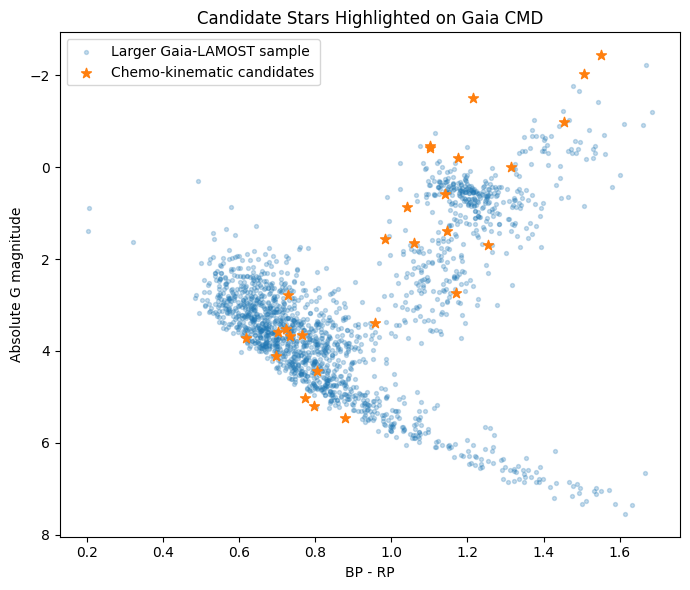

Saved: /Users/liors/Documents/gaia-lamost-galactic-archaeology/figures/gaia_lamost_candidate_cmd_highlight.png


In [10]:
plt.figure(figsize=(7, 6))

plt.scatter(
    features["bp_rp"],
    features["absolute_g_mag"],
    s=8,
    alpha=0.25,
    label="Larger Gaia-LAMOST sample"
)

plt.scatter(
    diag["bp_rp"],
    diag["absolute_g_mag"],
    s=55,
    marker="*",
    label="Chemo-kinematic candidates"
)

plt.gca().invert_yaxis()
plt.xlabel("BP - RP")
plt.ylabel("Absolute G magnitude")
plt.title("Candidate Stars Highlighted on Gaia CMD")
plt.legend()
plt.tight_layout()

cmd_output = FIGURES_DIR / "gaia_lamost_candidate_cmd_highlight.png"
plt.savefig(cmd_output, dpi=200)
plt.show()

print("Saved:", cmd_output)

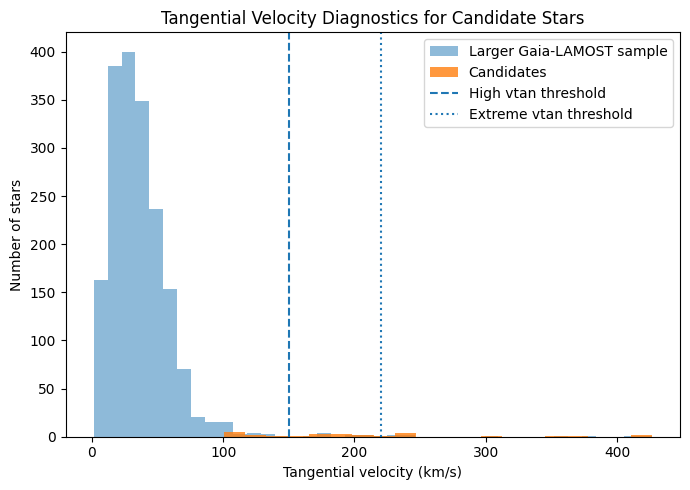

Saved: /Users/liors/Documents/gaia-lamost-galactic-archaeology/figures/gaia_lamost_candidate_velocity_diagnostics.png


In [11]:
plt.figure(figsize=(7, 5))

plt.hist(
    features["tangential_velocity_kms"].dropna(),
    bins=40,
    alpha=0.5,
    label="Larger Gaia-LAMOST sample"
)

plt.hist(
    diag["tangential_velocity_kms"].dropna(),
    bins=20,
    alpha=0.8,
    label="Candidates"
)

plt.axvline(150, linestyle="--", label="High vtan threshold")
plt.axvline(220, linestyle=":", label="Extreme vtan threshold")

plt.xlabel("Tangential velocity (km/s)")
plt.ylabel("Number of stars")
plt.title("Tangential Velocity Diagnostics for Candidate Stars")
plt.legend()
plt.tight_layout()

vel_output = FIGURES_DIR / "gaia_lamost_candidate_velocity_diagnostics.png"
plt.savefig(vel_output, dpi=200)
plt.show()

print("Saved:", vel_output)

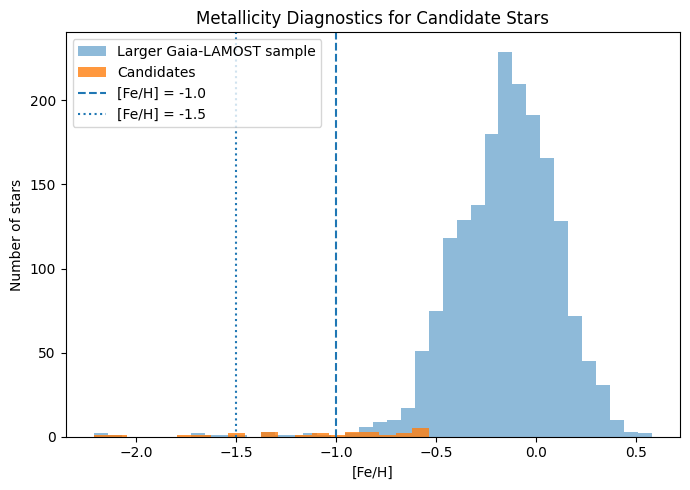

Saved: /Users/liors/Documents/gaia-lamost-galactic-archaeology/figures/gaia_lamost_candidate_metallicity_distribution.png


In [12]:
plt.figure(figsize=(7, 5))

plt.hist(
    features["feh"].dropna(),
    bins=40,
    alpha=0.5,
    label="Larger Gaia-LAMOST sample"
)

plt.hist(
    diag["feh"].dropna(),
    bins=20,
    alpha=0.8,
    label="Candidates"
)

plt.axvline(-1.0, linestyle="--", label="[Fe/H] = -1.0")
plt.axvline(-1.5, linestyle=":", label="[Fe/H] = -1.5")

plt.xlabel("[Fe/H]")
plt.ylabel("Number of stars")
plt.title("Metallicity Diagnostics for Candidate Stars")
plt.legend()
plt.tight_layout()

feh_output = FIGURES_DIR / "gaia_lamost_candidate_metallicity_distribution.png"
plt.savefig(feh_output, dpi=200)
plt.show()

print("Saved:", feh_output)

In [13]:
n_candidates = len(diag)
level_counts = diag["candidate_level_m6"].value_counts().to_dict()
score_counts = diag["candidate_score_m6"].value_counts().sort_index().to_dict()

print("Milestone 6 Summary")
print("===================")
print(f"Number of candidate stars analysed: {n_candidates}")
print(f"Candidate level counts: {level_counts}")
print(f"Candidate score counts: {score_counts}")

print("\nMetallicity diagnostics:")
print(f"Median [Fe/H] of candidates: {diag['feh'].median():.3f}")
print(f"Minimum [Fe/H] of candidates: {diag['feh'].min():.3f}")
print(f"Maximum [Fe/H] of candidates: {diag['feh'].max():.3f}")

print("\nVelocity diagnostics:")
print(f"Median tangential velocity of candidates: {diag['tangential_velocity_kms'].median():.3f} km/s")
print(f"Maximum tangential velocity of candidates: {diag['tangential_velocity_kms'].max():.3f} km/s")
print(f"Median Galactocentric total velocity of candidates: {diag['galcen_vtot_kms'].median():.3f} km/s")
print(f"Maximum Galactocentric total velocity of candidates: {diag['galcen_vtot_kms'].max():.3f} km/s")

print("\nOutput files:")
print(diagnostic_output)
print(summary_output)
print(md_output)
print(cmd_output)
print(vel_output)
print(feh_output)

Milestone 6 Summary
Number of candidate stars analysed: 27
Candidate level counts: {'weak': 12, 'moderate': 9, 'strong': 6}
Candidate score counts: {0: 4, 1: 8, 2: 7, 3: 2, 4: 3, 5: 3}

Metallicity diagnostics:
Median [Fe/H] of candidates: -0.951
Minimum [Fe/H] of candidates: -2.213
Maximum [Fe/H] of candidates: -0.534

Velocity diagnostics:
Median tangential velocity of candidates: 197.414 km/s
Maximum tangential velocity of candidates: 426.686 km/s
Median Galactocentric total velocity of candidates: 157.611 km/s
Maximum Galactocentric total velocity of candidates: 393.357 km/s

Output files:
/Users/liors/Documents/gaia-lamost-galactic-archaeology/data/processed/gaia_lamost_candidate_diagnostic_table.csv
/Users/liors/Documents/gaia-lamost-galactic-archaeology/data/processed/gaia_lamost_candidate_summary_table.csv
/Users/liors/Documents/gaia-lamost-galactic-archaeology/data/processed/gaia_lamost_candidate_summary_table.md
/Users/liors/Documents/gaia-lamost-galactic-archaeology/figures/